### Shared Blackboard Multi-Agent Insider Threat Detection


Key innovation: a Shared Blackboard (message bus) enables inter-agent communication:

  - Agent 1 (CAE) → writes scores + dynamic threshold + high-anomaly flag
  - Agent 2 (NLP) → reads CAE flag, boosts its own score for flagged sessions
  - Agent 3 (Temporal) → reads upstream flags, uses global baselines for flagged sessions
  - Agent 4 (Orchestrator) → reads all scores + evidence features from blackboard

Architecture:
  - Agent 1 (CAE)       → "How statistically abnormal is this session?" (general anomaly)
  - Agent 2 (DistilBERT)→ "Does text content indicate job search or data exfiltration?" (NLP classifier)
  - Agent 3 (Temporal)  → "How abnormal is this FOR THIS USER?" (context-aware)
  - Agent 4 (IF Orch.)  → Non-linear fusion of scores + inter-agent evidence

### Imports and Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pickle
from tqdm.auto import tqdm
from scipy.stats import rankdata
import matplotlib.pyplot as plt
import seaborn as sns
import gc

print("Libraries Imported")

Libraries Imported


In [2]:
CONFIG = {
    "processed_file": "../DatasetsProcessed/data_exfiltration_sessions_aggregated_dataset.csv",
    # --- Agent model paths ---
    "agent1_path": "../SavedModels/agent1_cae_new.pth",
    "agent2_model_dir": "../SavedModels/final_insider_threat_model",  # Fine-tuned DistilBERT
    "agent2_scanner": "all-mpnet-base-v2",                            # MPNet scanner model
    "agent3_path": "../SavedModels/agent3_baselines_new.pkl",
    "agent4_path": "../SavedModels/agent4_orchestrator_new.pkl",
    # --- Deployment artifact paths ---
    "scaler_path": "../SavedModels/scaler.pkl",
    "cae_threshold_path": "../SavedModels/cae_threshold.npy",
    "nlp_threshold_path": "../SavedModels/nlp_threshold.npy",
    "if_threshold_path": "../SavedModels/if_threshold.npy",
    # --- Device ---
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# --- Blackboard Configuration (tuneable) ---
CAE_THRESHOLD_SIGMA = 2.0      # mean + N*std for CAE dynamic threshold
NLP_BOOST_MULTIPLIER = 1.5     # boost factor for NLP when CAE flags high
NLP_FLAG_PERCENTILE = 90       # percentile above which NLP is considered "high"

# --- Downsampling Configuration ---
# Reduces compute time and false positive count from extreme class imbalance
DOWNSAMPLE_TRAIN = 100_000     # Max benign training samples (None = use all)
DOWNSAMPLE_TEST_BENIGN = 10_000  # Max benign test samples (None = use all)
# ALL malicious samples are ALWAYS retained regardless of downsampling

print(f"Running on device: {CONFIG['device']}")
print("Configuration loaded")

Running on device: cuda
Configuration loaded


### Loading Aggregated Sessions Dataset

In [3]:
if os.path.exists(CONFIG['processed_file']):
    print(f"Dataset Available: {CONFIG['processed_file']}")
    print("Loading Dataset...")
    full_df = pd.read_csv(CONFIG['processed_file'])

    # POST-LOAD FIXES
    # 1. Restore Datetime objects
    full_df['start'] = pd.to_datetime(full_df['start'])
    full_df['end']   = pd.to_datetime(full_df['end'])

    # 2. Handle Text Columns (NaNs become empty strings)
    text_cols = ['email_content_text', 'http_url_text', 'http_content_text', 'file_names_text', 'file_content_text']
    full_df[text_cols] = full_df[text_cols].fillna("")

else:
    raise FileNotFoundError(f"Processed Dataset not found at {CONFIG['processed_file']}")

print(f"Dataset Shape: {full_df.shape}")
print(f"Malicious Sessions: {full_df['label'].sum()}")
full_df.head()

Dataset Available: ../DatasetsProcessed/data_exfiltration_sessions_aggregated_dataset.csv
Loading Dataset...
Dataset Shape: (1948933, 21)
Malicious Sessions: 47


,user,start,end,duration,is_weekend,is_after_hour,emails_count,ext_emails_count,attachments_count,total_email_size,...,http_count,http_url_text,http_content_text,cloud_uploads_count,usb_connects_count,file_copies_count,file_to_usb_count,file_names_text,file_content_text,label
0,AAB0162,2010-01-04 07:41:00,2010-01-04 15:41:00,28800.0,0,0,9,1,2,2615549,...,72,http://barnesandnoble.com/Joseph_Szigeti/hubay...,"One of those, Testosterone, was filmed in 2003...",0,0,0,0,,,0
1,AAB0162,2010-01-05 07:46:00,2010-01-05 15:46:00,28800.0,0,0,8,0,3,2837712,...,62,http://pcmag.com/Bill_Ponsford/cripes/1996_Hav...,"In late 1996, the Justice Department opened a ...",0,0,0,0,,,0
2,AAB0162,2010-01-06 07:45:00,2010-01-06 15:45:00,28800.0,0,0,9,0,2,3028297,...,72,http://chase.com/Ediacara_biota/ediacara/Senax...,"Sinnock died in May 1947, before finishing the...",0,0,0,0,,,0
3,AAB0162,2010-01-07 07:45:00,2010-01-07 15:45:00,28800.0,0,0,7,1,1,2095245,...,75,http://foxsports.com/Psittacosaurus/psittacosa...,"In 1917-18, she was fitted with better rangefi...",0,0,0,0,,,0
4,AAB0162,2010-01-08 07:50:00,2010-01-08 15:50:00,28800.0,0,0,9,2,0,238896,...,47,http://pnc.com/Magnetosphere_of_Jupiter/rj/Oev...,"DePeyster also sent out Joseph Ainsse, a local...",0,0,0,0,,,0


### Preprocessing & Data Splitting

In [4]:
NUM_COLS = ['duration', 'is_weekend', 'is_after_hour', 'emails_count', 'ext_emails_count',
            'attachments_count', 'total_email_size', 'http_count', 'cloud_uploads_count',
            'usb_connects_count', 'file_copies_count', 'file_to_usb_count']

# Fit scaler on FULL data before downsampling (captures true data distribution)
scaler = MinMaxScaler()
scaler.fit(full_df[NUM_COLS])

# --- Step 1: Split benign / malicious ---
benign_df = full_df[full_df['label'] == 0]
malicious_df = full_df[full_df['label'] == 1]

train_size = int(len(benign_df) * 0.8)
train_benign_full = benign_df.iloc[:train_size]
test_benign_full = benign_df.iloc[train_size:]

print(f"\nBefore downsampling:")
print(f"  Training benign: {len(train_benign_full):,}")
print(f"  Testing benign:  {len(test_benign_full):,}")
print(f"  Malicious:       {len(malicious_df)}")

# --- Step 2: Downsample training benign (stratified random) ---
if DOWNSAMPLE_TRAIN is not None and len(train_benign_full) > DOWNSAMPLE_TRAIN:
    train_df = train_benign_full.sample(
        n=DOWNSAMPLE_TRAIN, random_state=42
    ).reset_index(drop=True)
    print(f"\n  ✓ Training downsampled: {len(train_benign_full):,} → {len(train_df):,}")
else:
    train_df = train_benign_full.reset_index(drop=True)
    print(f"\n  Training kept as-is: {len(train_df):,}")

# --- Step 3: Downsample test benign (keep ALL malicious) ---
if DOWNSAMPLE_TEST_BENIGN is not None and len(test_benign_full) > DOWNSAMPLE_TEST_BENIGN:
    test_benign_ds = test_benign_full.sample(
        n=DOWNSAMPLE_TEST_BENIGN, random_state=42
    )
    print(f"  ✓ Test benign downsampled: {len(test_benign_full):,} → {len(test_benign_ds):,}")
else:
    test_benign_ds = test_benign_full
    print(f"  Test benign kept as-is: {len(test_benign_ds):,}")

test_df = pd.concat([test_benign_ds, malicious_df]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(f"\nAfter downsampling:")
print(f"  Training Data (Normal Only): {len(train_df):,}")
print(f"  Testing Data (Mixed):        {len(test_df):,}")
print(f"    - Benign in test:    {(test_df['label']==0).sum():,}")
print(f"    - Malicious in test: {(test_df['label']==1).sum()}")
print(f"    - Imbalance ratio:   1:{(test_df['label']==0).sum() // max((test_df['label']==1).sum(), 1)}")

# SCALED tensors for Agent 1 only
X_train_num = torch.FloatTensor(scaler.transform(train_df[NUM_COLS])).to(CONFIG['device'])
X_test_num = torch.FloatTensor(scaler.transform(test_df[NUM_COLS])).to(CONFIG['device'])
y_test = test_df['label'].values

os.makedirs(os.path.dirname(CONFIG['scaler_path']), exist_ok=True)
with open(CONFIG['scaler_path'], 'wb') as f:
    pickle.dump(scaler, f)
print(f"\nScaler saved to {CONFIG['scaler_path']}")


Before downsampling:
  Training benign: 1,559,108
  Testing benign:  389,778
  Malicious:       47

  ✓ Training downsampled: 1,559,108 → 100,000
  ✓ Test benign downsampled: 389,778 → 10,000

After downsampling:
  Training Data (Normal Only): 100,000
  Testing Data (Mixed):        10,047
    - Benign in test:    10,000
    - Malicious in test: 47
    - Imbalance ratio:   1:212

Scaler saved to ../SavedModels/scaler.pkl


### Shared Blackboard: Inter-Agent Communication Hub

In [5]:
class Blackboard:
    """
    Shared communication hub for the multi-agent system.
    Agents write their scores, thresholds, and flags here.
    Downstream agents read upstream results to adapt their behavior.
    """
    def __init__(self, n_samples):
        self.n_samples = n_samples
        self.data = {}               # Storage for per-session arrays / scalars
        self.messages = []           # Ordered list of inter-agent messages

    def write(self, agent_name, key, value, msg=None):
        """Write a per-session array or scalar to the blackboard."""
        full_key = f"{agent_name}:{key}"
        self.data[full_key] = value
        if msg:
            self.messages.append({
                'agent': agent_name,
                'key': key,
                'msg': msg
            })
            print(f"  [Blackboard] {msg}")

    def read(self, agent_name, key):
        """Read a value from the blackboard. Returns None if not found."""
        return self.data.get(f"{agent_name}:{key}", None)

    def get_flag(self, agent_name, key):
        """Read a boolean flag array from the blackboard."""
        arr = self.read(agent_name, key)
        if arr is None:
            return np.zeros(self.n_samples, dtype=bool)
        return arr.astype(bool)

    def get_messages(self):
        """Return all inter-agent messages (for logging / orchestrator evidence)."""
        return list(self.messages)

    def summary(self):
        """Print a summary of all blackboard contents."""
        print(f"\n{'='*60}")
        print(f"  Blackboard Summary ({len(self.data)} entries, {len(self.messages)} messages)")
        print(f"{'='*60}")
        for key, val in self.data.items():
            if isinstance(val, np.ndarray):
                print(f"  {key}: ndarray shape={val.shape}, dtype={val.dtype}")
            else:
                print(f"  {key}: {type(val).__name__} = {val}")
        print()
        for m in self.messages:
            print(f"  [{m['agent']}] {m['msg']}")
        print(f"{'='*60}\n")

### Single Agent Evaluation Function

In [6]:
def evaluate_single_agent(agent_name, scores, y_true):
    """Evaluate an individual agent's scoring with ROC-AUC and optimal threshold."""
    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)
    print(f"\n{'='*60}")
    print(f"  {agent_name} — Individual Evaluation")
    print(f"{'='*60}")
    print(f"  ROC-AUC: {auc:.4f}")
    print(f"  Average Precision (AP): {ap:.6f}")

    precisions, recalls, thresholds_pr = precision_recall_curve(y_true, scores)
    target_recall = 0.90
    valid_mask = recalls[:-1] >= target_recall
    if valid_mask.any():
        best_idx = np.argmax(precisions[:-1][valid_mask])
        actual_indices = np.where(valid_mask)[0]
        chosen_idx = actual_indices[best_idx]
        best_threshold = thresholds_pr[chosen_idx]
        best_precision = precisions[chosen_idx]
        best_recall = recalls[chosen_idx]
    else:
        f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
        chosen_idx = np.argmax(f1_scores)
        best_threshold = thresholds_pr[chosen_idx]
        best_precision = precisions[chosen_idx]
        best_recall = recalls[chosen_idx]

    print(f"  Optimal threshold (recall≥{target_recall:.0%}): {best_threshold:.6f}")
    print(f"  → Precision: {best_precision:.4f}, Recall: {best_recall:.4f}")

    preds = (scores >= best_threshold).astype(int)
    print(f"\n  Classification Report at optimal threshold:")
    print(classification_report(y_true, preds, target_names=['Benign', 'Malicious']))

    n_mal = y_true.sum()
    n_detected = ((preds == 1) & (y_true == 1)).sum()
    n_fp = ((preds == 1) & (y_true == 0)).sum()
    print(f"  Malicious detected: {n_detected}/{n_mal}")
    print(f"  False positives: {n_fp}")

    return auc, scores

### Agent 1 - Contractive Autoencoder Model

In [7]:
class ContractiveAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ContractiveAutoencoder, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        # Decoder
        self.fc3 = nn.Linear(16, 32)
        self.fc4 = nn.Linear(32, input_dim)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        h1 = self.relu(self.fc1(x))
        h2 = self.sigmoid(self.fc2(h1)) # Latent code
        
        # Decoder
        h3 = self.relu(self.fc3(h2))
        recon = self.sigmoid(self.fc4(h3)) # Output normalized 0-1
        return recon, h2

def contractive_loss(model, x, recon, h, lam):
    """
    Computes MSE + Contractive Penalty (Jacobian)
    """
    mse = nn.MSELoss()(recon, x)
    
    # Extract weights of the layer producing the latent code (fc2)
    W = model.fc2.weight
    
    # Calculate contraction penalty
    # h is shape (batch, latent_dim)
    dh = h * (1 - h) # Derivative of sigmoid
    
    # Sum of squares of weights
    w_sum = torch.sum(W**2, dim=1) # shape (latent_dim)
    w_sum = w_sum.unsqueeze(0) # shape (1, latent_dim)
    
    # Frobenius norm of Jacobian
    contractive_penalty = torch.sum(dh**2 * w_sum) / x.size(0)
    
    return mse + (lam * contractive_penalty), mse

### Training Agent 1

Training CAE (Agent 1)...
Epoch 10/150, Loss: 7.928025
Epoch 20/150, Loss: 2.859871
Epoch 30/150, Loss: 1.648048
Epoch 40/150, Loss: 0.747656
Epoch 50/150, Loss: 0.506400
Epoch 60/150, Loss: 0.427493
Epoch 70/150, Loss: 0.349143
Epoch 80/150, Loss: 0.301394
Epoch 90/150, Loss: 0.261339
Epoch 100/150, Loss: 0.220644
Epoch 110/150, Loss: 0.186888
Epoch 120/150, Loss: 0.165293
Epoch 130/150, Loss: 0.150116
Epoch 140/150, Loss: 0.138555
Epoch 150/150, Loss: 0.129521
Agent 1 CAE model saved to ../SavedModels/agent1_cae_new.pth


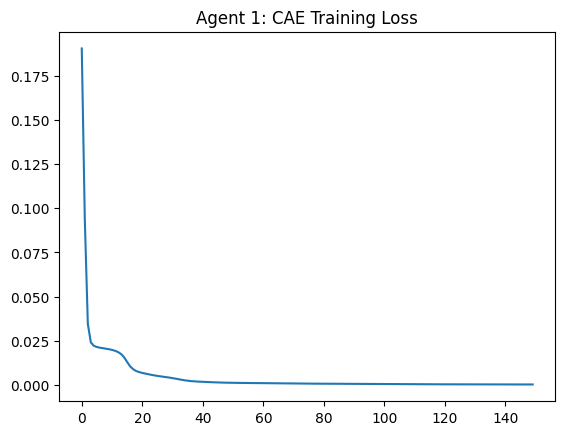

In [8]:
BATCH_SIZE = 256
EPOCHS = 150
LEARNING_RATE = 1e-4
LAMBDA_PENALTY = 1e-4
FORCE_RETRAIN_CAE = True  # Retrain on downsampled data

agent1_model = ContractiveAutoencoder(input_dim=len(NUM_COLS)).to(CONFIG['device'])
optimizer = optim.Adam(agent1_model.parameters(), lr=LEARNING_RATE)

if os.path.exists(CONFIG['agent1_path']) and not FORCE_RETRAIN_CAE:
    print(f"Found saved Agent 1 model at {CONFIG['agent1_path']}. Loading...")
    agent1_model.load_state_dict(
        torch.load(CONFIG['agent1_path'], map_location=CONFIG['device'])
    )
    agent1_model.eval()
else:
    print("Training CAE (Agent 1)...")
    train_loader = DataLoader(TensorDataset(X_train_num), batch_size=BATCH_SIZE, shuffle=True)
    loss_history = []
    for epoch in range(EPOCHS):
        total_loss = 0
        for batch in train_loader:
            x_batch = batch[0]
            optimizer.zero_grad()
            recon, latent = agent1_model(x_batch)
            loss, mse = contractive_loss(agent1_model, x_batch, recon, latent, LAMBDA_PENALTY)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        loss_history.append(total_loss / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.6f}")

    os.makedirs(os.path.dirname(CONFIG['agent1_path']), exist_ok=True)
    torch.save(agent1_model.state_dict(), CONFIG['agent1_path'])
    print(f"Agent 1 CAE model saved to {CONFIG['agent1_path']}")
    plt.plot(loss_history)
    plt.title("Agent 1: CAE Training Loss")
    plt.show()

### Agent 1 Evaluation

In [9]:
agent1_model.eval()
loss_fn = nn.MSELoss(reduction='none')

# Training errors → used to compute dynamic threshold
with torch.no_grad():
    recon_train, _ = agent1_model(X_train_num)
    train_recon_errors = torch.mean(loss_fn(recon_train, X_train_num), dim=1).cpu().numpy()

# Dynamic threshold: mean + CAE_THRESHOLD_SIGMA * std of benign training errors
cae_threshold = train_recon_errors.mean() + CAE_THRESHOLD_SIGMA * train_recon_errors.std()
print(f"\nAgent 1 Dynamic Threshold (mean + {CAE_THRESHOLD_SIGMA}σ): {cae_threshold:.6f}")
print(f"  Training errors — mean: {train_recon_errors.mean():.6f}, std: {train_recon_errors.std():.6f}")

# Test errors
with torch.no_grad():
    recon_test, _ = agent1_model(X_test_num)
    reconstruction_errors = torch.mean(loss_fn(recon_test, X_test_num), dim=1).cpu().numpy()

np.save(CONFIG['cae_threshold_path'], np.array(cae_threshold))
print(f"CAE threshold saved to {CONFIG['cae_threshold_path']}")


Agent 1 Dynamic Threshold (mean + 2.0σ): 0.001790
  Training errors — mean: 0.000269, std: 0.000760
CAE threshold saved to ../SavedModels/cae_threshold.npy


### Initialize Blackboard & Agent 1 Writes

In [10]:
print("\n" + "="*60)
print("  INITIALIZING SHARED BLACKBOARD")
print("="*60)

# Create blackboard for TEST data
bb_test = Blackboard(n_samples=len(test_df))

# Agent 1 writes to the blackboard
bb_test.write('agent1', 'scores', reconstruction_errors,
              msg=f"Agent1 wrote {len(reconstruction_errors)} reconstruction error scores")
bb_test.write('agent1', 'dynamic_threshold', cae_threshold,
              msg=f"Agent1 set dynamic threshold = {cae_threshold:.6f}")

cae_high_flag = reconstruction_errors > cae_threshold
n_flagged = cae_high_flag.sum()
bb_test.write('agent1', 'high_flag', cae_high_flag,
              msg=f"Agent1 flagged {n_flagged} sessions ({n_flagged/len(test_df)*100:.2f}%) above threshold")

# --- Agent 1 Evaluation ---
agent1_auc, _ = evaluate_single_agent("Agent 1 (CAE)", reconstruction_errors, y_test)

# Also create a blackboard for TRAINING data (for orchestrator training)
bb_train = Blackboard(n_samples=len(train_df))
train_cae_high_flag = train_recon_errors > cae_threshold
bb_train.write('agent1', 'scores', train_recon_errors)
bb_train.write('agent1', 'dynamic_threshold', cae_threshold)
bb_train.write('agent1', 'high_flag', train_cae_high_flag)


  INITIALIZING SHARED BLACKBOARD
  [Blackboard] Agent1 wrote 10047 reconstruction error scores
  [Blackboard] Agent1 set dynamic threshold = 0.001790
  [Blackboard] Agent1 flagged 193 sessions (1.92%) above threshold

  Agent 1 (CAE) — Individual Evaluation
  ROC-AUC: 0.7827
  Average Precision (AP): 0.012346
  Optimal threshold (recall≥90%): 0.000152
  → Precision: 0.0108, Recall: 0.9149

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.61      0.75     10000
   Malicious       0.01      0.91      0.02        47

    accuracy                           0.61     10047
   macro avg       0.51      0.76      0.39     10047
weighted avg       0.99      0.61      0.75     10047

  Malicious detected: 43/47
  False positives: 3944


### Agent 2 - MPNet Scanner + DistilBERT Classifier (with Blackboard Boost)

In [11]:
# Two-stage pipeline (from DistillBertLLMPredictions.ipynb):
#   Stage 1 (MPNet): Chunk text → encode → cosine similarity against anchor
#           texts (job search + exfiltration) → select most suspicious chunk.
#   Stage 2 (DistilBERT): Classify the selected chunk into 3 classes:
#           Normal (0), Job Search (1), Data Exfiltration (2).
#   The anomaly score = P(Job Search) + P(Data Exfiltration) = 1 - P(Normal).

class DistilBertThreatAgent:
    """
    Agent 2: Detects insider threat text patterns using a two-stage pipeline.

    Stage 1 (Scanner): MPNet embeddings + cosine similarity to threat anchors
                       to find the most suspicious text chunk per session.
    Stage 2 (Classifier): Fine-tuned DistilBERT classifies the chunk into
                          Normal / Job Search / Data Exfiltration.

    Score = P(threat) = 1 - P(normal) from softmax output.
    """

    # Anchor texts — encode the semantic "signature" of threat behaviors
    JOB_ANCHOR_TEXT = (
        "I want to quit my job. I am applying for a new position. "
        "looking for a new job, applying for positions, sending resume, interview, recruiter, linkedin, "
        "glassdoor, monster.com, taleo, careerbuilder, layoff rumors, downsizing anxiety, severance package, "
        "Boeing, Lockheed Martin, Raytheon, Northrop Grumman, mushrooms, suillus spraguei, bad date email signature, "
        "updating cv, reference check, salary negotiation"
    )

    EXFIL_ANCHOR_TEXT = (
        "I am stealing company secrets. I am uploading confidential files to a personal account. "
        "stealing proprietary data, uploading confidential files to cloud storage, dropbox, google drive, "
        "wikileaks, julian assange, the real story about dtaa, jainism, anekantavada, gandhi, "
        "m249 saw, fuzes, hazard analysis, strategic systems program, hms lion, uranus operation, cockatoo, "
        "copying files to usb, removable media, thumb drive, tor browser, encryption, steganography"
    )

    LABEL_MAP = {0: "Normal", 1: "Job Search", 2: "Data Exfiltration"}

    def __init__(self, scanner_model_name, classifier_dir, device):
        self.device = device

        # Stage 1: MPNet sentence encoder for chunk scanning
        print(f"Agent 2: Loading MPNet scanner ({scanner_model_name})...")
        self.scanner = SentenceTransformer(scanner_model_name, device=str(device))

        # Pre-encode anchor vectors
        self.anchor_job_vec = self.scanner.encode(self.JOB_ANCHOR_TEXT, convert_to_tensor=True)
        self.anchor_exfil_vec = self.scanner.encode(self.EXFIL_ANCHOR_TEXT, convert_to_tensor=True)

        # Stage 2: Fine-tuned DistilBERT classifier
        print(f"Agent 2: Loading fine-tuned DistilBERT from {classifier_dir}...")
        self.tokenizer = AutoTokenizer.from_pretrained(classifier_dir)
        self.classifier = AutoModelForSequenceClassification.from_pretrained(classifier_dir)
        self.classifier.to(device)
        self.classifier.eval()
        print("Agent 2: Models loaded.")

    def _prepare_full_text(self, df):
        """Concatenate all 5 text columns into a single string per session."""
        full_text = (
            "EMAIL: " + df['email_content_text'].fillna('').astype(str) +
            " | HTTP URL: " + df['http_url_text'].fillna('').astype(str) +
            " | HTTP CONTENT: " + df['http_content_text'].fillna('').astype(str) +
            " | FILE NAMES: " + df['file_names_text'].fillna('').astype(str) +
            " | FILE CONTENT: " + df['file_content_text'].fillna('').astype(str)
        )
        return full_text.tolist()

    def _get_best_snippet(self, text):
        """
        Stage 1: Chunk the text, encode with MPNet, find the chunk most similar
        to either the job-search or exfiltration anchor.
        """
        if pd.isna(text) or text.strip() == "":
            return ""

        chunk_size = 800
        overlap = 150
        chunks = [text[i:i + chunk_size] for i in range(0, len(text), chunk_size - overlap)]
        if not chunks:
            chunks = [text[:512]]
        chunks = chunks[:100]  # Cap at 100 chunks per session

        chunk_embeddings = self.scanner.encode(chunks, convert_to_tensor=True, show_progress_bar=False)

        scores_job = util.cos_sim(chunk_embeddings, self.anchor_job_vec).squeeze()
        scores_exfil = util.cos_sim(chunk_embeddings, self.anchor_exfil_vec).squeeze()

        if scores_job.ndim == 0:
            scores_job = scores_job.unsqueeze(0)
        if scores_exfil.ndim == 0:
            scores_exfil = scores_exfil.unsqueeze(0)

        max_scores, _ = torch.max(torch.stack([scores_job, scores_exfil]), dim=0)
        best_idx = torch.argmax(max_scores).item()
        return chunks[best_idx]

    def _classify_batch(self, snippets):
        """
        Stage 2: Classify snippets using fine-tuned DistilBERT.
        Returns per-class probabilities.
        """
        inputs = self.tokenizer(
            snippets, return_tensors="pt", padding=True,
            truncation=True, max_length=512
        ).to(self.device)

        with torch.no_grad():
            outputs = self.classifier(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        return probs.cpu().numpy()  # shape: (batch_size, 3)

    def predict_score(self, df, batch_size=16):
        """
        Full two-stage prediction. Returns anomaly scores:
            score = P(Job Search) + P(Data Exfiltration) = 1 - P(Normal)
        Higher score = more likely a threat.
        """
        print("Agent 2: Preparing text data...")
        texts = self._prepare_full_text(df)
        all_threat_probs = np.zeros(len(texts))
        all_pred_labels = np.zeros(len(texts), dtype=int)

        print(f"Agent 2: Running MPNet Scanner + DistilBERT Classifier on {len(texts):,} sessions...")
        for i in tqdm(range(0, len(texts), batch_size), desc="Agent 2 (DistilBERT)"):
            batch_texts = texts[i:i + batch_size]

            # Stage 1: Find most suspicious chunk per session
            snippets = [self._get_best_snippet(t) for t in batch_texts]

            # Handle empty snippets (sessions with no text)
            non_empty_mask = [bool(s.strip()) for s in snippets]
            if any(non_empty_mask):
                non_empty_snippets = [s for s, m in zip(snippets, non_empty_mask) if m]
                non_empty_indices = [j for j, m in enumerate(non_empty_mask) if m]

                # Stage 2: Classify
                probs = self._classify_batch(non_empty_snippets)  # (n, 3)
                # Threat probability = 1 - P(Normal) = P(Job) + P(Exfil)
                threat_probs = 1.0 - probs[:, 0]
                pred_labels = np.argmax(probs, axis=1)

                for idx, orig_idx in enumerate(non_empty_indices):
                    all_threat_probs[i + orig_idx] = threat_probs[idx]
                    all_pred_labels[i + orig_idx] = pred_labels[idx]

        # Log class distribution
        for cls_id, cls_name in self.LABEL_MAP.items():
            count = (all_pred_labels == cls_id).sum()
            print(f"  Agent 2: {cls_name}: {count:,} sessions")

        return all_threat_probs, all_pred_labels

    def predict_score_with_blackboard(self, df, blackboard, boost_multiplier=1.5, batch_size=16):
        """
        Blackboard-aware scoring:
        - Computes base DistilBERT threat scores
        - Reads Agent 1's high_flag
        - Boosts threat score by `boost_multiplier` for sessions flagged by CAE
        """
        base_scores, pred_labels = self.predict_score(df, batch_size=batch_size)

        # Read CAE flag from blackboard
        cae_high_flag = blackboard.get_flag('agent1', 'high_flag')

        if cae_high_flag is not None and cae_high_flag.any():
            n_boosted = cae_high_flag.sum()
            # Boost: clamp to [0, 1] since these are probabilities
            boosted_scores = np.where(
                cae_high_flag,
                np.clip(base_scores * boost_multiplier, 0, 1),
                base_scores
            )
            blackboard.write('agent2', 'scores', boosted_scores,
                             msg=f"Agent2 (DistilBERT) boosted {n_boosted} sessions by "
                                 f"{boost_multiplier}x based on Agent1 high_flag")
            blackboard.write('agent2', 'base_scores', base_scores,
                             msg=f"Agent2 stored unboosted threat probabilities for comparison")
            blackboard.write('agent2', 'pred_labels', pred_labels,
                             msg=f"Agent2 stored 3-class predictions (0=Normal, 1=Job, 2=Exfil)")
            return boosted_scores
        else:
            blackboard.write('agent2', 'scores', base_scores,
                             msg="Agent2 (DistilBERT) ran without blackboard boost (no Agent1 flags)")
            blackboard.write('agent2', 'base_scores', base_scores)
            blackboard.write('agent2', 'pred_labels', pred_labels)
            return base_scores


# --- Agent 2: Load pre-trained models (no training needed — model is already fine-tuned) ---
print("\nInitializing Agent 2 (MPNet + DistilBERT)...")
agent2 = DistilBertThreatAgent(
    scanner_model_name=CONFIG['agent2_scanner'],
    classifier_dir=CONFIG['agent2_model_dir'],
    device=CONFIG['device']
)


Initializing Agent 2 (MPNet + DistilBERT)...
Agent 2: Loading MPNet scanner (all-mpnet-base-v2)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Agent 2: Loading fine-tuned DistilBERT from ../SavedModels/final_insider_threat_model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Agent 2: Models loaded.


### Agent 2 — Blackboard-Aware Scoring + Evaluation

In [12]:
# Score TEST data with blackboard boost
semantic_scores = agent2.predict_score_with_blackboard(
    test_df, bb_test, boost_multiplier=NLP_BOOST_MULTIPLIER
)

# Write NLP high flag to blackboard
nlp_threshold = np.percentile(semantic_scores, NLP_FLAG_PERCENTILE)
nlp_high_flag = semantic_scores > nlp_threshold
bb_test.write('agent2', 'high_flag', nlp_high_flag,
              msg=f"Agent2 flagged {nlp_high_flag.sum()} sessions above "
                  f"P{NLP_FLAG_PERCENTILE} threshold = {nlp_threshold:.4f}")

agent2_auc, _ = evaluate_single_agent("Agent 2 (DistilBERT + Boost)", semantic_scores, y_test)

np.save(CONFIG['nlp_threshold_path'], np.array(nlp_threshold))
print(f"NLP threshold saved to {CONFIG['nlp_threshold_path']}")

Agent 2: Preparing text data...
Agent 2: Running MPNet Scanner + DistilBERT Classifier on 10,047 sessions...


Agent 2 (DistilBERT):   0%|          | 0/628 [00:00<?, ?it/s]

  Agent 2: Normal: 9,873 sessions
  Agent 2: Job Search: 120 sessions
  Agent 2: Data Exfiltration: 54 sessions
  [Blackboard] Agent2 (DistilBERT) boosted 193 sessions by 1.5x based on Agent1 high_flag
  [Blackboard] Agent2 stored unboosted threat probabilities for comparison
  [Blackboard] Agent2 stored 3-class predictions (0=Normal, 1=Job, 2=Exfil)
  [Blackboard] Agent2 flagged 1005 sessions above P90 threshold = 0.0882

  Agent 2 (DistilBERT + Boost) — Individual Evaluation
  ROC-AUC: 0.9347
  Average Precision (AP): 0.227192
  Optimal threshold (recall≥90%): 0.042229
  → Precision: 0.0185, Recall: 0.9149

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.77      0.87     10000
   Malicious       0.02      0.91      0.04        47

    accuracy                           0.77     10047
   macro avg       0.51      0.84      0.45     10047
weighted avg       0.99      0.77      0.87     10047

  Maliciou

In [13]:
# Score TRAINING data with blackboard boost (for orchestrator training)
train_semantic_scores = agent2.predict_score_with_blackboard(
    train_df, bb_train, boost_multiplier=NLP_BOOST_MULTIPLIER
)
train_nlp_high_flag = train_semantic_scores > nlp_threshold
bb_train.write('agent2', 'high_flag', train_nlp_high_flag)

# Free GPU memory after inference
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Agent 2: Preparing text data...
Agent 2: Running MPNet Scanner + DistilBERT Classifier on 100,000 sessions...


Agent 2 (DistilBERT):   0%|          | 0/6250 [00:00<?, ?it/s]

  Agent 2: Normal: 98,400 sessions
  Agent 2: Job Search: 1,026 sessions
  Agent 2: Data Exfiltration: 574 sessions
  [Blackboard] Agent2 (DistilBERT) boosted 1648 sessions by 1.5x based on Agent1 high_flag
  [Blackboard] Agent2 stored unboosted threat probabilities for comparison
  [Blackboard] Agent2 stored 3-class predictions (0=Normal, 1=Job, 2=Exfil)


### Agent 3 - Temporal/Behavioral Baseline Agent with Blackboard Context

In [14]:
FORCE_RETRAIN_TEMPORAL = True

class TemporalBaselineAgent:
    def __init__(self, feature_cols):
        self.feature_cols = feature_cols
        self.user_means = None
        self.user_stds = None
        self.global_mean = None
        self.global_std = None

    def fit(self, train_df):
        print("Agent 3: Building Historical User Baselines (on RAW features)...")
        self.global_mean = train_df[self.feature_cols].astype(np.float64).mean()
        self.global_std = train_df[self.feature_cols].astype(np.float64).std().replace(0, 1e-6)

        grouped = train_df.groupby('user')[self.feature_cols]
        self.user_means = grouped.mean()
        self.user_stds = grouped.std()

        for col in self.feature_cols:
            self.user_means[col] = self.user_means[col].fillna(self.global_mean[col])
            self.user_stds[col] = (
                self.user_stds[col].fillna(self.global_std[col]).replace(0, 1e-6)
            )

        print(f"Agent 3: Baselines built for {len(self.user_means)} unique users.")

    def predict_score(self, test_df):
        """Base per-user Z-score deviation (no blackboard)."""
        means_dict = self.user_means.to_dict('index')
        stds_dict = self.user_stds.to_dict('index')

        x = test_df[self.feature_cols].values.astype(np.float64)
        means = np.zeros(x.shape, dtype=np.float64)
        stds = np.ones(x.shape, dtype=np.float64)

        for i, user in enumerate(test_df['user']):
            if user in means_dict:
                means[i] = list(means_dict[user].values())
                stds[i] = list(stds_dict[user].values())
            else:
                means[i] = self.global_mean.values
                stds[i] = self.global_std.values

        stds = np.maximum(stds, 1e-6)
        z_scores = (x - means) / stds
        z_scores = np.clip(z_scores, -10.0, 10.0)
        temporal_anomaly_scores = np.sqrt(np.mean(z_scores**2, axis=1))
        return temporal_anomaly_scores

    def _compute_global_z_scores(self, test_df):
        """
        Compute Z-scores using GLOBAL baselines (all users' mean/std).
        Used for deeper context when upstream agents flag a session.
        This is the 'wider 30-day window' equivalent — comparing against
        the entire population instead of just the individual user.
        """
        x = test_df[self.feature_cols].values.astype(np.float64)
        global_means = np.tile(self.global_mean.values, (len(x), 1))
        global_stds = np.tile(self.global_std.values, (len(x), 1))
        global_stds = np.maximum(global_stds, 1e-6)

        z_scores = (x - global_means) / global_stds
        z_scores = np.clip(z_scores, -10.0, 10.0)
        return np.sqrt(np.mean(z_scores**2, axis=1))

    def predict_score_with_blackboard(self, test_df, blackboard):
        """
        Blackboard-aware scoring:
        - Reads Agent 1 and Agent 2 high_flag
        - For sessions flagged by either upstream agent, also compute
          global Z-scores and take max(per-user, global)
        """
        print("Agent 3: Computing per-user Z-Score Deviations...")
        base_scores = self.predict_score(test_df)

        # Read upstream flags
        cae_high = blackboard.get_flag('agent1', 'high_flag')
        nlp_high = blackboard.get_flag('agent2', 'high_flag')

        # Sessions flagged by either upstream agent
        upstream_flagged = cae_high | nlp_high
        n_flagged = upstream_flagged.sum()

        if n_flagged > 0:
            print(f"Agent 3: {n_flagged} sessions flagged by upstream agents — computing global baselines...")
            global_scores = self._compute_global_z_scores(test_df)
            # Use max(per-user, global) for flagged sessions → deeper context
            enhanced_scores = np.where(upstream_flagged,
                                       np.maximum(base_scores, global_scores),
                                       base_scores)
            blackboard.write('agent3', 'scores', enhanced_scores,
                             msg=f"Agent3 enhanced {n_flagged} sessions with global baselines "
                                 f"(max of per-user and global Z-scores)")
            blackboard.write('agent3', 'base_scores', base_scores,
                             msg=f"Agent3 stored base per-user scores for comparison")
            return enhanced_scores
        else:
            print("Agent 3: No upstream flags — using standard per-user scoring.")
            blackboard.write('agent3', 'scores', base_scores,
                             msg="Agent3 ran without enhancement (no upstream flags)")
            blackboard.write('agent3', 'base_scores', base_scores)
            return base_scores

    def save(self, path):
        data = {
            'user_means': self.user_means, 'user_stds': self.user_stds,
            'global_mean': self.global_mean, 'global_std': self.global_std
        }
        with open(path, 'wb') as f:
            pickle.dump(data, f)

    def load(self, path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.user_means = data['user_means']
        self.user_stds = data['user_stds']
        self.global_mean = data['global_mean']
        self.global_std = data['global_std']


### Agent 3 Training

In [15]:
agent3 = TemporalBaselineAgent(feature_cols=NUM_COLS)
if os.path.exists(CONFIG['agent3_path']) and not FORCE_RETRAIN_TEMPORAL:
    print(f"Loading Agent 3 from {CONFIG['agent3_path']}...")
    agent3.load(CONFIG['agent3_path'])
else:
    print("Training Agent 3...")
    agent3.fit(train_df)
    os.makedirs(os.path.dirname(CONFIG['agent3_path']), exist_ok=True)
    agent3.save(CONFIG['agent3_path'])
    print(f"Agent 3 saved to {CONFIG['agent3_path']}")

Training Agent 3...
Agent 3: Building Historical User Baselines (on RAW features)...
Agent 3: Baselines built for 3190 unique users.
Agent 3 saved to ../SavedModels/agent3_baselines_new.pkl


### Agent 3 Evaluation

In [16]:
temporal_scores = agent3.predict_score_with_blackboard(test_df, bb_test)
agent3_auc, _ = evaluate_single_agent("Agent 3 (Temporal + Blackboard Context)",
                                      temporal_scores, y_test)

# Score training data
train_temporal_scores = agent3.predict_score_with_blackboard(train_df, bb_train)


Agent 3: Computing per-user Z-Score Deviations...
Agent 3: 1162 sessions flagged by upstream agents — computing global baselines...
  [Blackboard] Agent3 enhanced 1162 sessions with global baselines (max of per-user and global Z-scores)
  [Blackboard] Agent3 stored base per-user scores for comparison

  Agent 3 (Temporal + Blackboard Context) — Individual Evaluation
  ROC-AUC: 0.7285
  Average Precision (AP): 0.067439
  Optimal threshold (recall≥90%): 0.623124
  → Precision: 0.0082, Recall: 0.9149

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.48      0.65     10000
   Malicious       0.01      0.91      0.02        47

    accuracy                           0.48     10047
   macro avg       0.50      0.70      0.33     10047
weighted avg       0.99      0.48      0.64     10047

  Malicious detected: 43/47
  False positives: 5215
Agent 3: Computing per-user Z-Score Deviations...
Agent 3: 11200 sessio

### Blackboard Summary

In [17]:
bb_test.summary()


  Blackboard Summary (9 entries, 9 messages)
  agent1:scores: ndarray shape=(10047,), dtype=float32
  agent1:dynamic_threshold: float32 = 0.0017895271303132176
  agent1:high_flag: ndarray shape=(10047,), dtype=bool
  agent2:scores: ndarray shape=(10047,), dtype=float64
  agent2:base_scores: ndarray shape=(10047,), dtype=float64
  agent2:pred_labels: ndarray shape=(10047,), dtype=int64
  agent2:high_flag: ndarray shape=(10047,), dtype=bool
  agent3:scores: ndarray shape=(10047,), dtype=float64
  agent3:base_scores: ndarray shape=(10047,), dtype=float64

  [agent1] Agent1 wrote 10047 reconstruction error scores
  [agent1] Agent1 set dynamic threshold = 0.001790
  [agent1] Agent1 flagged 193 sessions (1.92%) above threshold
  [agent2] Agent2 (DistilBERT) boosted 193 sessions by 1.5x based on Agent1 high_flag
  [agent2] Agent2 stored unboosted threat probabilities for comparison
  [agent2] Agent2 stored 3-class predictions (0=Normal, 1=Job, 2=Exfil)
  [agent2] Agent2 flagged 1005 sessions

#### Build Feature Matrix for Orchestrator with Blackboard Evidence

In [18]:
def build_orchestrator_features(score_cae, score_nlp, score_temp):
    """Base orchestrator feature matrix (from V8.1)."""
    features = np.column_stack([
        score_cae,
        score_nlp,
        score_temp,
        score_cae * score_temp,
        score_cae * score_nlp,
        score_temp * score_nlp,
        np.max([score_cae, score_temp, score_nlp], axis=0),
        np.std([score_cae, score_temp, score_nlp], axis=0),
    ])
    return features

def build_orchestrator_features_with_blackboard(bb):
    """
    Build enriched orchestrator features including blackboard evidence.
    Adds: CAE flag (binary), upstream consensus count (0-3).
    """
    score_cae = bb.read('agent1', 'scores')
    score_nlp = bb.read('agent2', 'scores')
    score_temp = bb.read('agent3', 'scores')

    # Standard features
    base_features = build_orchestrator_features(score_cae, score_nlp, score_temp)

    # --- NEW: Blackboard evidence features ---
    cae_flag = bb.get_flag('agent1', 'high_flag').astype(float)
    nlp_flag = bb.get_flag('agent2', 'high_flag').astype(float)

    # Temporal flag: top 10% of temporal scores
    temp_threshold = np.percentile(score_temp, 90)
    temp_flag = (score_temp > temp_threshold).astype(float)

    # Consensus: how many agents independently flagged this session?
    upstream_agreement = cae_flag + nlp_flag + temp_flag

    enriched_features = np.column_stack([
        base_features,
        cae_flag,              # Binary: did CAE flag this?
        upstream_agreement,    # Count: how many agents flagged? (0-3)
    ])

    return enriched_features


FEATURE_NAMES = [
    'CAE_score', 'DistilBERT_score', 'Temporal_score',
    'CAE×Temporal', 'CAE×DistilBERT', 'Temporal×DistilBERT',
    'Max_score', 'Score_std',
    'CAE_flag', 'Upstream_agreement'  # Blackboard evidence
]

# Build training features
X_orch_train = build_orchestrator_features_with_blackboard(bb_train)

# Build test features
X_orch_test = build_orchestrator_features_with_blackboard(bb_test)

print(f"\nOrchestrator training features: {X_orch_train.shape}")
print(f"Orchestrator test features:     {X_orch_test.shape}")
print(f"Feature names: {FEATURE_NAMES}")


Orchestrator training features: (100000, 10)
Orchestrator test features:     (10047, 10)
Feature names: ['CAE_score', 'DistilBERT_score', 'Temporal_score', 'CAE×Temporal', 'CAE×DistilBERT', 'Temporal×DistilBERT', 'Max_score', 'Score_std', 'CAE_flag', 'Upstream_agreement']


### Agent 4 — Isolation Forest Orchestrator (Semi-Supervised)

In [19]:
FORCE_RETRAIN_ORCHESTRATOR = True

if os.path.exists(CONFIG['agent4_path']) and not FORCE_RETRAIN_ORCHESTRATOR:
    print(f"Loading Agent 4 Orchestrator from {CONFIG['agent4_path']}...")
    with open(CONFIG['agent4_path'], 'rb') as f:
        orchestrator_if = pickle.load(f)
else:
    print("\nTraining Agent 4: Isolation Forest Orchestrator...")
    print(f"  Training on {len(X_orch_train):,} benign score patterns")
    print(f"  Feature dimensions: {X_orch_train.shape[1]} ({', '.join(FEATURE_NAMES)})")

    orchestrator_if = IsolationForest(
        n_estimators=300,
        contamination='auto',
        max_samples='auto',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    orchestrator_if.fit(X_orch_train)

    os.makedirs(os.path.dirname(CONFIG['agent4_path']), exist_ok=True)
    with open(CONFIG['agent4_path'], 'wb') as f:
        pickle.dump(orchestrator_if, f)
    print(f"  Agent 4 Orchestrator saved to {CONFIG['agent4_path']}")

# Score test data with IF
if_raw_scores = orchestrator_if.score_samples(X_orch_test)
final_scores_if = -if_raw_scores  # Negate: higher = more anomalous

print(f"\n  IF score range: [{final_scores_if.min():.4f}, {final_scores_if.max():.4f}]")
print(f"  IF score mean (benign): {final_scores_if[y_test == 0].mean():.4f}")
print(f"  IF score mean (malicious): {final_scores_if[y_test == 1].mean():.4f}")



Training Agent 4: Isolation Forest Orchestrator...
  Training on 100,000 benign score patterns
  Feature dimensions: 10 (CAE_score, DistilBERT_score, Temporal_score, CAE×Temporal, CAE×DistilBERT, Temporal×DistilBERT, Max_score, Score_std, CAE_flag, Upstream_agreement)
  Agent 4 Orchestrator saved to ../SavedModels/agent4_orchestrator_new.pkl

  IF score range: [0.3381, 0.8377]
  IF score mean (benign): 0.4127
  IF score mean (malicious): 0.6230


### Agent 4 (IF) Evaluation

In [20]:
if_auc, _ = evaluate_single_agent("Agent 4 (IF Orchestrator + Blackboard Evidence)",
                                  final_scores_if, y_test)


  Agent 4 (IF Orchestrator + Blackboard Evidence) — Individual Evaluation
  ROC-AUC: 0.9052
  Average Precision (AP): 0.070838
  Optimal threshold (recall≥90%): 0.447187
  → Precision: 0.0187, Recall: 0.9149

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.77      0.87     10000
   Malicious       0.02      0.91      0.04        47

    accuracy                           0.78     10047
   macro avg       0.51      0.84      0.45     10047
weighted avg       0.99      0.78      0.87     10047

  Malicious detected: 43/47
  False positives: 2256


### Linear Fusion Baseline (for comparison)

In [21]:
def normalize_rank(arr):
    return rankdata(arr) / len(arr)

norm_cae = normalize_rank(reconstruction_errors)
norm_nlp = normalize_rank(semantic_scores)
norm_temp = normalize_rank(temporal_scores)

w_cae = 0.40
w_temp = 0.30
w_nlp = 0.30

final_scores_linear = (w_cae * norm_cae) + (w_temp * norm_temp) + (w_nlp * norm_nlp)
linear_auc = roc_auc_score(y_test, final_scores_linear)
linear_ap = average_precision_score(y_test, final_scores_linear)

print(f"\n{'='*60}")
print(f"  Linear Fusion Baseline")
print(f"{'='*60}")
print(f"  Linear ROC-AUC: {linear_auc:.4f}")
print(f"  Linear Average Precision: {linear_ap:.6f}")


  Linear Fusion Baseline
  Linear ROC-AUC: 0.9098
  Linear Average Precision: 0.049835


### Threshold Analysis — IF Orchestrator

In [22]:
print(f"\n{'='*60}")
print(f"  Threshold Analysis — IF Orchestrator")
print(f"{'='*60}")

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, final_scores_if)

for target in [1.0, 0.95, 0.90, 0.85, 0.80]:
    valid_mask = recalls[:-1] >= target
    if valid_mask.any():
        valid_precisions = precisions[:-1][valid_mask]
        best_local_idx = np.argmax(valid_precisions)
        actual_indices = np.where(valid_mask)[0]
        chosen_idx = actual_indices[best_local_idx]
        t = thresholds_pr[chosen_idx]
        p = precisions[chosen_idx]
        r = recalls[chosen_idx]
        preds_temp = (final_scores_if >= t).astype(int)
        n_mal = y_test.sum()
        n_detected = ((preds_temp == 1) & (y_test == 1)).sum()
        n_fp = ((preds_temp == 1) & (y_test == 0)).sum()
        print(f"\n  Target recall ≥ {target:.0%}:")
        print(f"    Threshold: {t:.6f}, Precision: {p:.4f}, Recall: {r:.4f}")
        print(f"    Malicious detected: {n_detected}/{n_mal}, False positives: {n_fp}")

# Select best threshold: 100% recall if possible, else 90%
best_target = 1.0
valid_mask = recalls[:-1] >= best_target
if not valid_mask.any():
    best_target = 0.90
    valid_mask = recalls[:-1] >= best_target

if valid_mask.any():
    valid_precisions = precisions[:-1][valid_mask]
    best_local_idx = np.argmax(valid_precisions)
    actual_indices = np.where(valid_mask)[0]
    chosen_idx = actual_indices[best_local_idx]
    threshold = thresholds_pr[chosen_idx]
else:
    threshold = 0.0

predictions = (final_scores_if >= threshold).astype(int)

n_detected = ((predictions == 1) & (y_test == 1)).sum()
n_mal = y_test.sum()
print(f"\n  *** Selected threshold: {threshold:.6f} ***")
print(f"  *** Malicious detected: {n_detected}/{n_mal} ***")

np.save(CONFIG['if_threshold_path'], np.array(threshold))
print(f"IF orchestrator threshold saved to {CONFIG['if_threshold_path']}  (value: {threshold:.6f})")



  Threshold Analysis — IF Orchestrator

  Target recall ≥ 100%:
    Threshold: 0.346501, Precision: 0.0056, Recall: 1.0000
    Malicious detected: 47/47, False positives: 8366

  Target recall ≥ 95%:
    Threshold: 0.389353, Precision: 0.0109, Recall: 0.9574
    Malicious detected: 45/47, False positives: 4086

  Target recall ≥ 90%:
    Threshold: 0.447187, Precision: 0.0187, Recall: 0.9149
    Malicious detected: 43/47, False positives: 2256

  Target recall ≥ 85%:
    Threshold: 0.492205, Precision: 0.0256, Recall: 0.8511
    Malicious detected: 40/47, False positives: 1524

  Target recall ≥ 80%:
    Threshold: 0.508506, Precision: 0.0271, Recall: 0.8085
    Malicious detected: 38/47, False positives: 1366

  *** Selected threshold: 0.346501 ***
  *** Malicious detected: 47/47 ***
IF orchestrator threshold saved to ../SavedModels/if_threshold.npy  (value: 0.346501)


In [23]:
print(f"\n{'='*60}")
print(f"  Final Classification Report (IF Orchestrator + Blackboard)")
print(f"{'='*60}")
print(classification_report(y_test, predictions, target_names=['Benign', 'Malicious']))
print(f"ROC-AUC Score: {if_auc:.4f}")


  Final Classification Report (IF Orchestrator + Blackboard)
              precision    recall  f1-score   support

      Benign       1.00      0.16      0.28     10000
   Malicious       0.01      1.00      0.01        47

    accuracy                           0.17     10047
   macro avg       0.50      0.58      0.15     10047
weighted avg       1.00      0.17      0.28     10047

ROC-AUC Score: 0.9052


### Score Distribution Plot

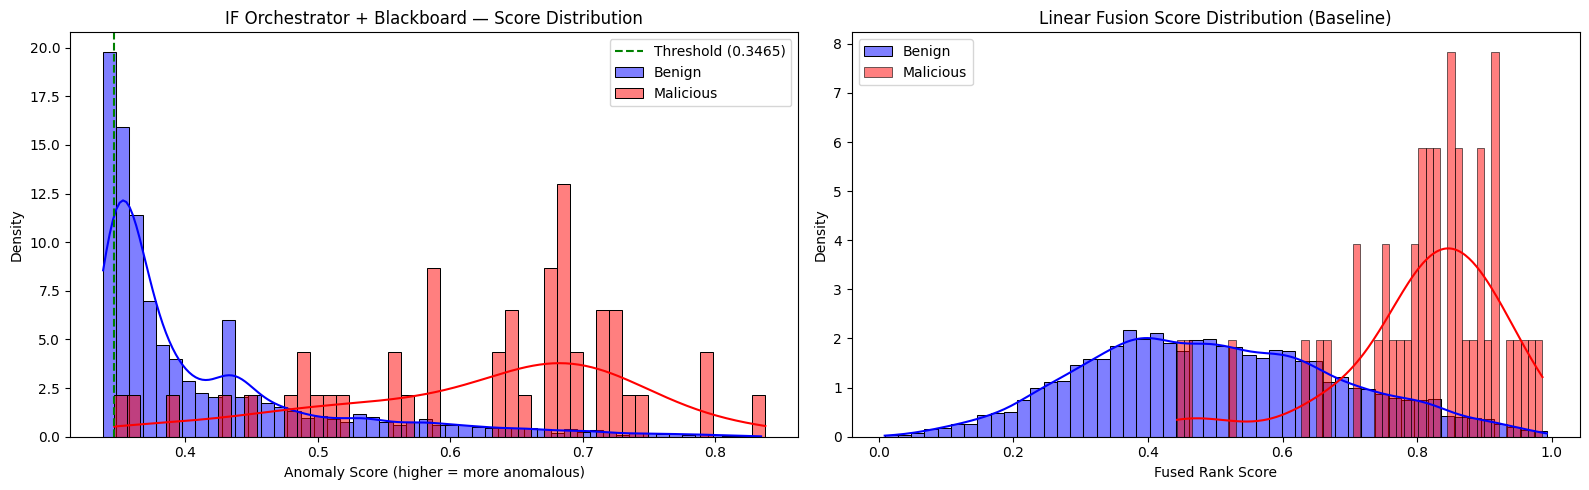

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
sns.histplot(final_scores_if[y_test == 0], color='blue', label='Benign',
             kde=True, stat="density", bins=50, ax=ax1)
sns.histplot(final_scores_if[y_test == 1], color='red', label='Malicious',
             kde=True, stat="density", bins=50, ax=ax1)
ax1.axvline(threshold, color='green', linestyle='--', label=f"Threshold ({threshold:.4f})")
ax1.set_title("IF Orchestrator + Blackboard — Score Distribution")
ax1.set_xlabel("Anomaly Score (higher = more anomalous)")
ax1.set_ylabel("Density")
ax1.legend()

ax2 = axes[1]
sns.histplot(final_scores_linear[y_test == 0], color='blue', label='Benign',
             kde=True, stat="density", bins=50, ax=ax2)
sns.histplot(final_scores_linear[y_test == 1], color='red', label='Malicious',
             kde=True, stat="density", bins=50, ax=ax2)
ax2.set_title("Linear Fusion Score Distribution (Baseline)")
ax2.set_xlabel("Fused Rank Score")
ax2.set_ylabel("Density")
ax2.legend()

plt.tight_layout()
plt.show()

### Confusion Matrix

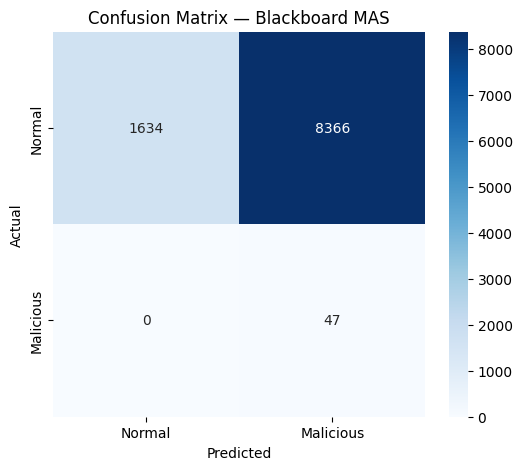

In [25]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Malicious'],
            yticklabels=['Normal', 'Malicious'])
plt.title("Confusion Matrix — Blackboard MAS")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ROC Curve

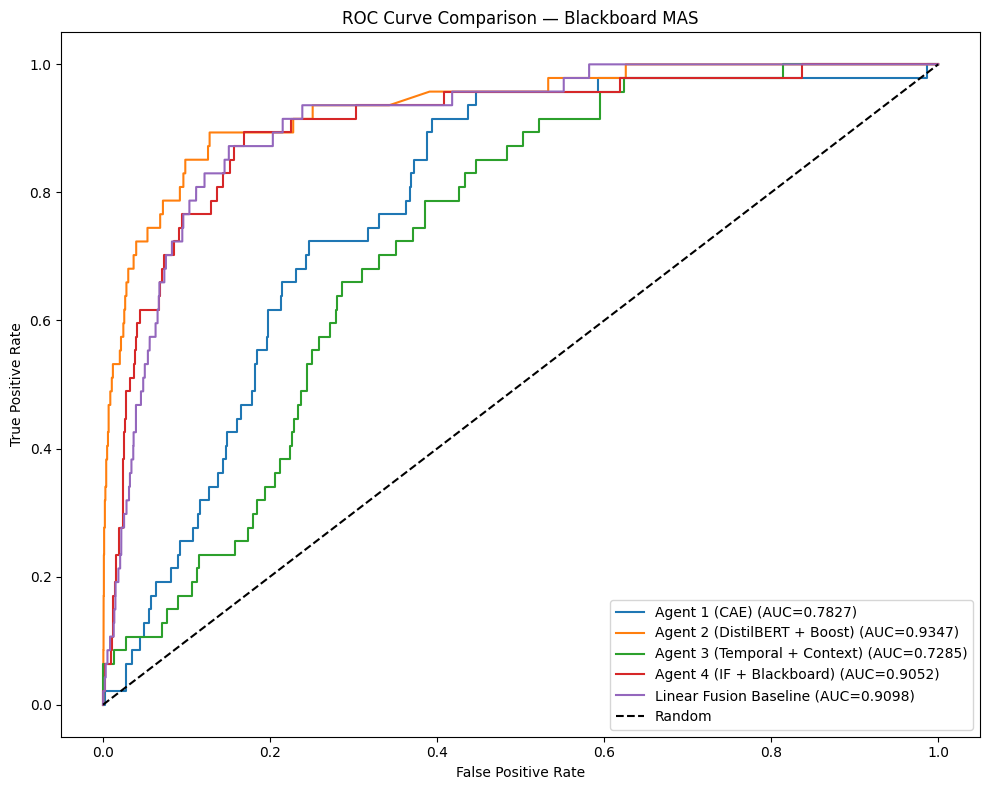

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, scores, auc_val in [
    ("Agent 1 (CAE)", reconstruction_errors, agent1_auc),
    ("Agent 2 (DistilBERT + Boost)", semantic_scores, agent2_auc),
    ("Agent 3 (Temporal + Context)", temporal_scores, agent3_auc),
    ("Agent 4 (IF + Blackboard)", final_scores_if, if_auc),
    ("Linear Fusion Baseline", final_scores_linear, linear_auc),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison — Blackboard MAS")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Summary

In [27]:
print(f"\n{'='*60}")
print(f"  FINAL SUMMARY — Multi-Agent System V10 (Shared Blackboard)")
print(f"{'='*60}")
print(f"")
print(f"  --- Data Configuration ---")
print(f"  Training samples:    {len(train_df):,} (downsampled from full benign)")
print(f"  Test samples:        {len(test_df):,} ({(test_df['label']==0).sum():,} benign + {(test_df['label']==1).sum()} malicious)")
print(f"  Imbalance ratio:     1:{(test_df['label']==0).sum() // max((test_df['label']==1).sum(), 1)}")
print(f"")
print(f"  --- Agent Performance ---")
print(f"  Agent 1 (CAE)                    ROC-AUC: {agent1_auc:.4f}")
print(f"  Agent 2 (DistilBERT + Boost)     ROC-AUC: {agent2_auc:.4f}")
print(f"  Agent 3 (Temporal + Context)     ROC-AUC: {agent3_auc:.4f}")
print(f"  Agent 4 (IF + Blackboard)        ROC-AUC: {if_auc:.4f}")
print(f"  Linear Fusion Baseline           ROC-AUC: {linear_auc:.4f}")
print(f"")
print(f"  --- Blackboard Communication ---")
print(f"  Messages Exchanged:  {len(bb_test.get_messages())}")
print(f"  CAE Dynamic Threshold: {cae_threshold:.6f}")
print(f"  NLP Boost Multiplier:  {NLP_BOOST_MULTIPLIER}")
print(f"  Sessions CAE-flagged:  {bb_test.get_flag('agent1', 'high_flag').sum()}")
print(f"  Sessions NLP-flagged:  {bb_test.get_flag('agent2', 'high_flag').sum()}")
print(f"")
print(f"  --- Detection Results ---")
n_detected_final = ((predictions == 1) & (y_test == 1)).sum()
n_fp_final = ((predictions == 1) & (y_test == 0)).sum()
print(f"  Malicious detected:  {n_detected_final}/{y_test.sum()} ({n_detected_final/max(y_test.sum(),1)*100:.1f}%)")
print(f"  False positives:     {n_fp_final}")
print(f"  False positive rate: {n_fp_final/max((y_test==0).sum(),1)*100:.2f}%")
print(f"{'='*60}")


  FINAL SUMMARY — Multi-Agent System V10 (Shared Blackboard)

  --- Data Configuration ---
  Training samples:    100,000 (downsampled from full benign)
  Test samples:        10,047 (10,000 benign + 47 malicious)
  Imbalance ratio:     1:212

  --- Agent Performance ---
  Agent 1 (CAE)                    ROC-AUC: 0.7827
  Agent 2 (DistilBERT + Boost)     ROC-AUC: 0.9347
  Agent 3 (Temporal + Context)     ROC-AUC: 0.7285
  Agent 4 (IF + Blackboard)        ROC-AUC: 0.9052
  Linear Fusion Baseline           ROC-AUC: 0.9098

  --- Blackboard Communication ---
  Messages Exchanged:  9
  CAE Dynamic Threshold: 0.001790
  NLP Boost Multiplier:  1.5
  Sessions CAE-flagged:  193
  Sessions NLP-flagged:  1005

  --- Detection Results ---
  Malicious detected:  47/47 (100.0%)
  False positives:     8366
  False positive rate: 83.66%
